In [112]:
import pandas as pd
import numpy as np
import matplotlib as mpl

In [113]:
pd.read_csv("matches.csv").head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [114]:
df = pd.read_csv("matches.csv")

In [141]:
#Q1
season_matches = df.groupby("season")["season"].count().reset_index(name = "Total matches played").rename(columns = {"season":"Season"})
print(season_matches.to_string(index = False))

 Season  Total matches played
   2008                    58
   2009                    57
   2010                    60
   2011                    73
   2012                    74
   2013                    76
   2014                    60
   2015                    59
   2016                    60
   2017                    59
   2018                    60
   2019                    60


In [116]:
#Q2
#we can also use print(df.groupby("winner")["winner"].count().to_frame("Total wins"))
#use to_frame to data structures.
#reseto_index gives table index numbers for each row.
#rename_axis("team name") changes actual column name to be mentioned to get renamed but only when reset_index isnt used.
#to_string is usedto convert table into tsring with many in built features like index=False to hide index, header=False, col_space = 15 for 15 units separation between columns
print(df.groupby("winner").size().reset_index(name="Total wins").rename(columns={"winner":"Team name"}).to_string(index=False, col_space=50))

                                         Team name                                         Total wins
                               Chennai Super Kings                                                100
                                   Deccan Chargers                                                 29
                                    Delhi Capitals                                                 10
                                  Delhi Daredevils                                                 67
                                     Gujarat Lions                                                 13
                                   Kings XI Punjab                                                 82
                              Kochi Tuskers Kerala                                                  6
                             Kolkata Knight Riders                                                 92
                                    Mumbai Indians                                

In [117]:
#Q3
#idxmax() takes the raw name of maximum count whereas max() considers that attributes maximum value.
toss = df.groupby("toss_winner").size()
high_toss_team = toss.idxmax()
high_toss_count = toss.max()
print(f"The team winning most tosses is {high_toss_team} with {high_toss_count} wins")

The team winning most tosses is Mumbai Indians with 98 wins


In [118]:
#Q4
print(df.groupby(["toss_winner","toss_decision"]).size().reset_index(name = "Frequency of opting").rename(columns={"toss_winner":"Team","toss_decision":"Toss decision"}).to_string(index = False, col_space = 25))

                       Team             Toss decision       Frequency of opting
        Chennai Super Kings                       bat                        48
        Chennai Super Kings                     field                        41
            Deccan Chargers                       bat                        24
            Deccan Chargers                     field                        19
             Delhi Capitals                       bat                         2
             Delhi Capitals                     field                         8
           Delhi Daredevils                       bat                        29
           Delhi Daredevils                     field                        51
              Gujarat Lions                       bat                         1
              Gujarat Lions                     field                        14
            Kings XI Punjab                       bat                        26
            Kings XI Punjab             

In [119]:
#Q5
#nlargest is used sort a particular table in descending order base on arguements we give like count of how many and which column.
#keep all is used to not leaving out someone jut because of their alphabetical order with same number of credits which eventually expands size of table and get all tied entities into table too for last position.
mom_list = df.groupby("player_of_match").size().reset_index(name = "Total M.O.M awards").rename(columns={"player_of_match":"Player"})
mom_10_list= mom_list.nlargest(10,"Total M.O.M awards", keep = "all").to_string(index=False, col_space = 45)
print(mom_10_list)

                                       Player                            Total M.O.M awards
                                     CH Gayle                                            21
                               AB de Villiers                                            20
                                    DA Warner                                            17
                                     MS Dhoni                                            17
                                    RG Sharma                                            17
                                    YK Pathan                                            16
                                    SR Watson                                            15
                                     SK Raina                                            14
                                    G Gambhir                                            13
                                    AM Rahane                                   

In [120]:
#Q6
venue_list = df.groupby("venue").size().reset_index(name = "Total matches played in this venue").rename(columns={"venue":"Venue"})
venue_10_list= venue_list.nlargest(10,"Total matches played in this venue", keep = "all").to_string(index=False, col_space = 45)
print(venue_10_list)

                                        Venue            Total matches played in this venue
                                 Eden Gardens                                            77
                        M Chinnaswamy Stadium                                            73
                             Wankhede Stadium                                            73
                             Feroz Shah Kotla                                            67
    Rajiv Gandhi International Stadium, Uppal                                            56
              MA Chidambaram Stadium, Chepauk                                            49
                       Sawai Mansingh Stadium                                            47
   Punjab Cricket Association Stadium, Mohali                                            35
      Maharashtra Cricket Association Stadium                                            21
                   Dr DY Patil Sports Academy                                   

In [121]:
#Q7
#sort_values is used to sort values based on a column and arrange it in ascending or descending order.
#drop_duplicates is used for not considering all repeating values and can ask to consider first or last reading. For particular reading you should use .nth(index_no).  
season_winners = df.groupby(["season","winner"]).size().reset_index(name = "No of matches won").rename(columns={"season":"Season","winner":"Team"})
sorted_season_winners=season_winners.sort_values(by = ["Season","No of matches won"], ascending = True)
print(sorted_season_winners.drop_duplicates(subset=["Season"],keep = "last").to_string(index = False, max_rows = None, max_cols = None))

 Season                  Team  No of matches won
   2008      Rajasthan Royals                 13
   2009      Delhi Daredevils                 10
   2010        Mumbai Indians                 11
   2011   Chennai Super Kings                 11
   2012 Kolkata Knight Riders                 12
   2013        Mumbai Indians                 13
   2014       Kings XI Punjab                 12
   2015        Mumbai Indians                 10
   2016   Sunrisers Hyderabad                 11
   2017        Mumbai Indians                 12
   2018   Chennai Super Kings                 11
   2019        Mumbai Indians                 11


In [122]:
#Q8
print(df.groupby("winner")["win_by_runs"].mean().round(2).reset_index(name="Avg of win by runs").rename(columns={"winner":"Team"}).sort_values(by = "Avg of win by runs", ascending = False).to_string(index=False, col_space = 25))

                       Team        Avg of win by runs
        Chennai Super Kings                     17.78
             Mumbai Indians                     17.12
Royal Challengers Bangalore                     14.90
            Deccan Chargers                     14.52
     Rising Pune Supergiant                     12.30
        Sunrisers Hyderabad                     12.29
           Rajasthan Royals                     11.93
      Kolkata Knight Riders                     11.80
              Pune Warriors                     11.58
            Kings XI Punjab                     11.28
    Rising Pune Supergiants                     10.60
           Delhi Daredevils                     10.07
             Delhi Capitals                      9.20
       Kochi Tuskers Kerala                      3.83
              Gujarat Lions                      0.08


In [123]:
#Q9
team_wise = df.groupby("winner")
max_win_by_runs = team_wise["win_by_runs"].max().reset_index(name = "Wins by maximum runs").rename(columns = {"winner":"Team"})
only_runs_wins_list = df[df["win_by_runs"]>0]
min_win_by_runs = only_runs_wins_list.groupby("winner")["win_by_runs"].min().reset_index(name = "Wins by minimum runs").rename(columns = {"winner":"Team"})
print(max_win_by_runs,"\n",min_win_by_runs)

                           Team  Wins by maximum runs
0           Chennai Super Kings                    97
1               Deccan Chargers                    82
2                Delhi Capitals                    39
3              Delhi Daredevils                    97
4                 Gujarat Lions                     1
5               Kings XI Punjab                   111
6          Kochi Tuskers Kerala                    17
7         Kolkata Knight Riders                   140
8                Mumbai Indians                   146
9                 Pune Warriors                    38
10             Rajasthan Royals                   105
11       Rising Pune Supergiant                    61
12      Rising Pune Supergiants                    34
13  Royal Challengers Bangalore                   144
14          Sunrisers Hyderabad                   118 
                            Team  Wins by minimum runs
0           Chennai Super Kings                     1
1               Deccan Cha

In [124]:
print(pd.merge(max_win_by_runs,min_win_by_runs))

                           Team  Wins by maximum runs  Wins by minimum runs
0           Chennai Super Kings                    97                     1
1               Deccan Chargers                    82                     6
2                Delhi Capitals                    39                    16
3              Delhi Daredevils                    97                     1
4                 Gujarat Lions                     1                     1
5               Kings XI Punjab                   111                     1
6          Kochi Tuskers Kerala                    17                     6
7         Kolkata Knight Riders                   140                     2
8                Mumbai Indians                   146                     1
9                 Pune Warriors                    38                     7
10             Rajasthan Royals                   105                     2
11       Rising Pune Supergiant                    61                     3
12      Risi

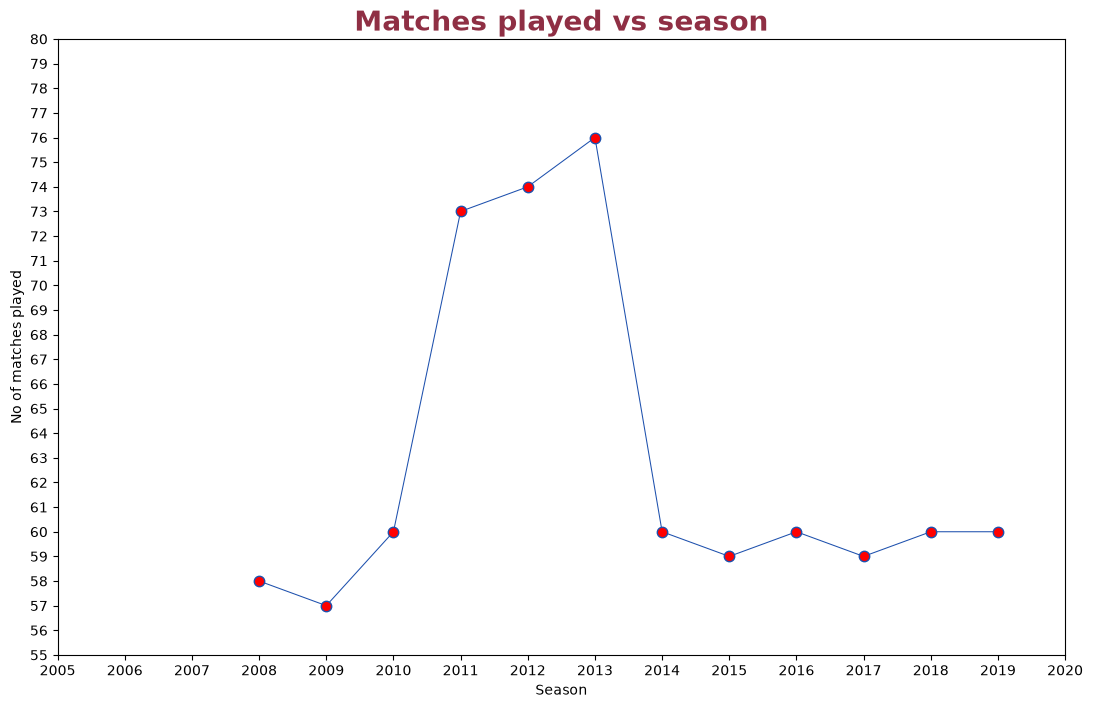

In [192]:
#Q10
#.pyplot is for plotting graphs
#.figure is for fixing dimensions of figure in which graph should be plotted
#.title is for mentioning title of graph
#.xlabel and .ylabel is for naming those axis labels
#.xticks and .yticks is for giving readings on x and y axi respectively
#plt.show() is for giving us output
#marker is for determining that point with anything. mfc means marker face color to change colour of marker in which you can even keep colour as text or even pick from colour and give its code.
#usual color for colour of line and linewidth for width of line.we can use linestyle for changing lin efrom solid to dotted, dashed and dashdot.
#use markeredgecolor for changing edge color of marker.
#You can customize labels and titles too by fontsize,color and fontweight inside parameters of plt.title or plt.labels
import matplotlib.pyplot as plt
x_range = np.arange(2005,2021,1)
y_range = np.arange(55,81,1)
plt.figure(figsize=(13,8))
x=season_matches["Season"]
y=season_matches["Total matches played"]
plt.plot(x,y,marker=".", markersize = 15,mfc="red",color = "#1d50ad",linewidth=0.75)
plt.title("Matches played vs season",fontsize=20,color = "#8f2f44", fontweight="bold")
plt.xlabel("Season")
plt.ylabel("No of matches played")
plt.xticks(x_range)
plt.yticks(y_range)
plt.show()